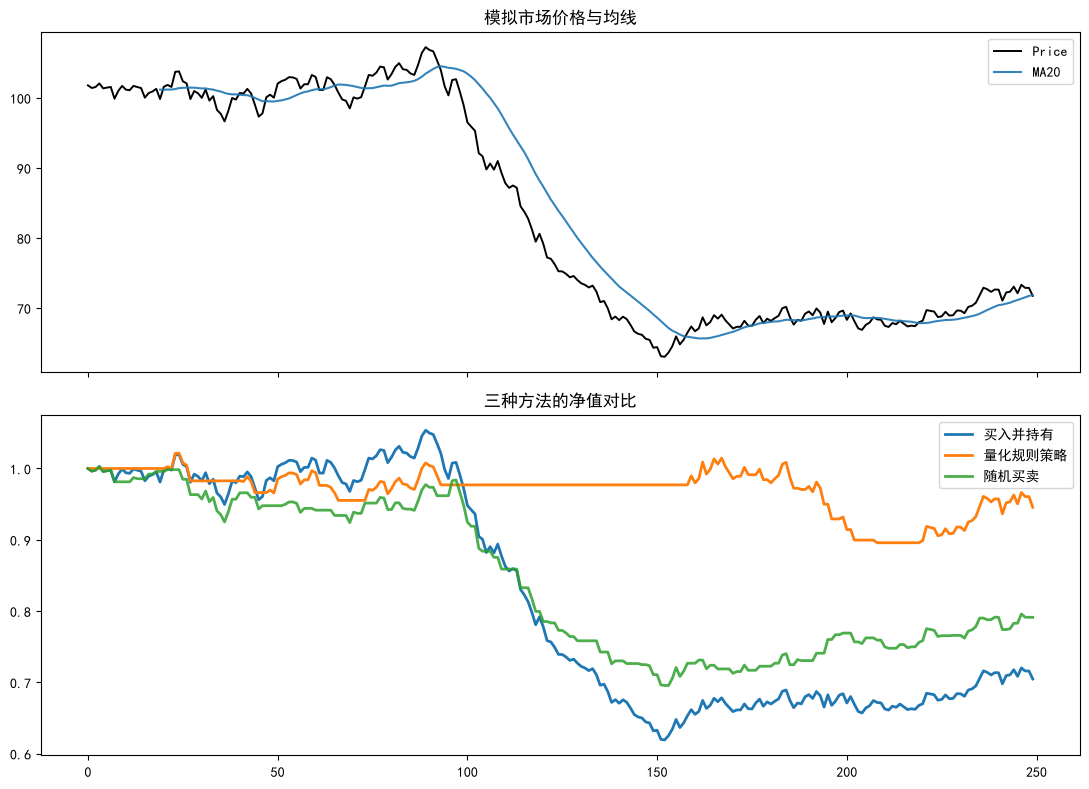

In [1]:
# ========== 导入本实验需要的库 ==========
import numpy as np              # 做数值计算（随机数、累乘价格等）
import pandas as pd             # 处理表格数据（像 Excel 一张表）
import matplotlib.pyplot as plt   # 画折线图、对比图

# ========== 让图表能正确显示中文 ==========
plt.rcParams['font.sans-serif'] = ['SimHei']   # 指定中文字体（Windows 常用黑体）
plt.rcParams['axes.unicode_minus'] = False    # 让坐标轴上的负号正常显示
np.random.seed(7)                             # 固定随机种子：每次运行随机数相同，方便对照

# ========== 第1步：模拟三段行情（涨→跌→恢复）==========
n1, n2, n3 = 90, 40, 120                      # 三个阶段分别有多少个交易日
ret = np.r_[                                    # 把三段「日收益率」拼成一条长数组
    np.random.normal(0.0010, 0.010, n1),        # 阶段1：平均每天略涨，波动较小
    np.random.normal(-0.012, 0.015, n2),       # 阶段2：平均每天偏跌，波动更大
    np.random.normal(0.0012, 0.012, n3)        # 阶段3：震荡恢复
]                                              # 数组拼接结束
price = 100 * np.cumprod(1 + ret)              # 起点100元，每天按 (1+收益率) 连乘得到价格

# ========== 第2步：做成 DataFrame，并算每日涨跌比例 ==========
df = pd.DataFrame({"close": price})            # 把价格放进表格，列名叫 close
df["ret"] = df["close"].pct_change().fillna(0) # pct_change = 日收益率；第一天填 0

# ========== 第3步：量化规则——收盘价在20日均线上方就持有 ==========
df["ma20"] = df["close"].rolling(20).mean()    # rolling(20).mean() = 20日移动平均线
df["signal_quant"] = (df["close"] > df["ma20"]).astype(int)  # 高于均线记1，否则记0

# ========== 第4步：随机买卖策略（对照组，乱买乱卖）==========
rng = np.random.default_rng(7)                 # 随机数生成器（种子7）
df["signal_random"] = rng.integers(0, 2, size=len(df))  # 每天随机 0 或 1

# ========== 第5步：算各策略的日收益（信号用昨天的，避免偷看未来）==========
df["ret_quant"] = df["signal_quant"].shift(1).fillna(0) * df["ret"]    # 量化策略收益
df["ret_random"] = df["signal_random"].shift(1).fillna(0) * df["ret"]  # 随机策略收益
df["ret_buyhold"] = df["ret"]                                          # 买入并持有：天天在场

# ========== 第6步：把日收益连乘成「净值曲线」（起点相当于1块钱）==========
for col in ["ret_quant", "ret_random", "ret_buyhold"]:   # 遍历三种收益列
    df[f"nav_{col}"] = (1 + df[col]).cumprod()         # (1+r) 连乘 = 累计净值

# ========== 第7步：画图——上图价格+均线，下图三种净值 ==========
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)  # 2行1列子图，共用横轴

axes[0].plot(df["close"], label="Price", color="black", linewidth=1.4)  # 模拟收盘价
axes[0].plot(df["ma20"], label="MA20", color="tab:blue", alpha=0.9)     # 20日均线
axes[0].set_title("模拟市场价格与均线")                                  # 子图标题
axes[0].legend()                                                        # 显示图例

axes[1].plot(df["nav_ret_buyhold"], label="买入并持有", linewidth=2)       # 买入持有净值
axes[1].plot(df["nav_ret_quant"], label="量化规则策略", linewidth=2)     # 规则策略净值
axes[1].plot(df["nav_ret_random"], label="随机买卖", linewidth=2, alpha=0.85)  # 随机策略
axes[1].set_title("三种方法的净值对比")                  # 下图标题
axes[1].legend()                                    # 显示下图图例

plt.tight_layout()   # 自动调整子图间距，避免标签被裁切
plt.show()           # 在 Notebook 里显示图片
